# Flux upper limits from NITRATES

In [ ]:
# ---- User inputs ----
work_dir = '/Users/sjs8171/Desktop/acme_tutorials/nitrates/785996578_c0'
temporal_bin_s = 16
sigma_ul = 5.0
nside_out = 32
output_fits = f'{work_dir}/ul_skymap.fits'

# Paths to UL response files (.rsp)
resp_dir_override = '/Users/sjs8171/Desktop/NITRATES/tests/nitrates_resp_dir/rsps4limits2/'
#resp_dir_override_2 = '/Users/sjs8171/Desktop/NITRATES/tests/nitrates_resp_dir/rsps4limits2/'

# spectrum options: 'band' or 'comp'
spectrum_model = 'band'

# For Band
band_alpha = -1.0
band_beta = -2.3
band_epeak_keV = 1000

# For Comptonized
comp_alpha = -0.62
comp_epeak_keV = 185.0

# flux integration range (keV)
flux_elo_keV = 15.0
flux_ehi_keV = 350.0

In [55]:
import os
import numpy as np
from astropy.io import fits
from astropy.table import Table
import healpy as hp
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from nitrates.lib.event2dpi_funcs import mask_detxy
from nitrates.lib.sqlite_funcs import get_conn
from nitrates.lib.dbread_funcs import get_info_tab
from nitrates.lib.coord_conv_funcs import convert_theta_phi2radec
from nitrates.analysis_seeds.do_full_rates import Linear_Rates
from nitrates.lib.calc_BAT_ul import get_resp4ul_tab, rate2band_eflux, rate2comp_eflux
from nitrates.config import resp_dname

def build_interpolator(ras, decs, vals):
    pts = np.column_stack((ras, decs))
    lin = LinearNDInterpolator(pts, vals, fill_value=np.nan)
    nn = NearestNDInterpolator(pts, vals)
    def f(ra, dec):
        v = lin(ra, dec)
        if np.isnan(v):
            return float(nn(ra, dec))
        return float(v)
    return f

def compute_rate_upper_limit(bkg_obj, trigger_time, dur, sigma=5.0, dtmin=-20.0, dtmax=20.0):
    tstep = dur / 4.0
    tbins0 = np.arange(dtmin, dtmax, tstep) + trigger_time
    tbins1 = tbins0 + dur

    sig2_bkg_vals = []
    for t0, t1 in zip(tbins0, tbins1):
        d = t1 - t0
        tmid = 0.5 * (t0 + t1)
        bkg_rate, bkg_rate_err = bkg_obj.get_rate(tmid)
        sig2_bkg = (bkg_rate_err * d) ** 2 + (bkg_rate * d)
        sig2_bkg_vals.append(sig2_bkg)

    rate_std = np.sqrt(np.max(sig2_bkg_vals)) / dur
    return sigma * rate_std

## Steps behind the flux upper limit (UL)

This notebook follows the same logic used in `UL.py`.
Below, each step is linked to the function(s) that perform it.

1. **Background fluctuation for a time bin** $\Delta t$  
   For each trial window around trigger time, define
   $$
   \sigma^2_{\mathrm{bkg}} = (\sigma_r\,\Delta t)^2 + r_{\mathrm{bkg}}\,\Delta t
   $$
   where $r_{\mathrm{bkg}}$ and $\sigma_r$ come from the background fit.

   **Functions used:**
   - `Linear_Rates(...).do_fits()` builds the background model in time.
   - `bkg_obj.get_rate(tmid)` returns $r_{\mathrm{bkg}}$ and $\sigma_r$ at each trial midpoint.
   - `compute_rate_upper_limit(...)` computes $\sigma^2_{\mathrm{bkg}}$ over all windows.

2. **Rate upper limit at significance $N_\sigma$**  
   Using the worst-case variance across scanned windows:
   $$
   \sigma_{\mathrm{rate}} = \frac{\sqrt{\max(\sigma^2_{\mathrm{bkg}})}}{\Delta t},
   \qquad
   r_{\mathrm{UL}} = N_\sigma\,\sigma_{\mathrm{rate}}
   $$
   In this notebook $N_\sigma = 5$ by default.

   **Functions used:**
   - `compute_rate_upper_limit(...)` returns $r_{\mathrm{UL}}$.

3. **Convert count-rate UL to energy-flux UL (assumed spectrum)**  
   For each sky direction (each DRM):
   - load the DRM,
   - scale by active-detector fraction,
   - assume spectral model (Band or Comptonized),
   - solve normalization that reproduces $r_{\mathrm{UL}}$,
   - integrate in the chosen energy range to get
   $$
   F_{\mathrm{UL}}\;[\mathrm{erg\,cm^{-2}\,s^{-1}}].
   $$

   **Functions used:**
   - `get_resp_tab_local(...)` loads the response file for each $(\theta,\phi)$.
   - `rate2band_eflux(...)` converts rate UL to flux UL for a Band spectrum.
   - `rate2comp_eflux(...)` converts rate UL to flux UL for a Comptonized spectrum.

4. **Sky map construction**  
   Directional values $F_{\mathrm{UL}}(\alpha,\delta)$ are interpolated over the sphere and sampled on a HEALPix grid, then written to FITS.

   **Functions used:**
   - `build_interpolator(ras, decs, vals)` builds the sky interpolation function.
   - `hp.pix2ang(...)` maps HEALPix pixel index to sky coordinates.
   - `hp.write_map(...)` writes the UL sky map in FITS format.

5. **Read UL at a given sky position**  
   Once the FITS map is written, the UL at any $(\mathrm{RA},\mathrm{Dec})$ is obtained by selecting the corresponding HEALPix pixel.

   **Functions used:**
   - `ul_at_radec(...)` wrapper for point queries.
   - `hp.ang2pix(...)` converts $(\mathrm{RA},\mathrm{Dec})$ to pixel index.
   - `hp.read_map(...)` loads the UL FITS map.

## Data loading and response-grid setup

This section prepares all inputs needed by the UL computation.

1. **Load trigger metadata and event products**
   - Opens `results.db` and reads trigger MET.
   - Loads event data, GTIs, detector mask, and attitude.

   **Functions used:**
   - `get_conn(...)`, `get_info_tab(...)`
   - `fits.open(...)`, `Table.read(...)`

2. **Build event selection and background model**
   - Applies quality/energy/time cuts to events.
   - Fits the background model used later for rate UL.

   **Functions used:**
   - `mask_detxy(...)` for detector-quality masking
   - `Linear_Rates(...)` and `bkg_obj.do_fits()` for background fitting

3. **Discover response files (.rsp)**
   - Resolves one or more response directories.
   - Collects all `.rsp` files and removes duplicated filenames.

   **Functions used:**
   - `os.path.isdir(...)`, `os.listdir(...)`

4. **Build sky-direction arrays from response filenames**
   - Extracts $(\theta,\phi)$ from each filename.
   - Converts to sky coordinates $(\mathrm{RA},\mathrm{Dec})$ for interpolation.

   **Functions used:**
   - `convert_theta_phi2radec(...)`

5. **Define local response loader per direction**
   - `get_resp_tab_local(theta, phi, rsp_dir)` opens the exact DRM for each direction.

   **Functions used:**
   - `Table.read(...)`

In [62]:
# ---- Load prepared NITRATES products ----
import nitrates.lib.calc_BAT_ul as calc_bat_ul

conn = get_conn(os.path.join(work_dir, 'results.db'))
info_tab = get_info_tab(conn)
trigger_time = info_tab['trigtimeMET'][0]

evfname = os.path.join(work_dir, 'filter_evdata.fits')
ev_data = fits.open(evfname)[1].data
GTI_PNT = Table.read(evfname, hdu='GTI_POINTING')
dmask = fits.open(os.path.join(work_dir, 'detmask.fits'))[0].data
attfile = fits.open(os.path.join(work_dir, 'attitude.fits'))[1].data
att_q = attfile['QPARAM'][np.argmin(np.abs(attfile['TIME'] - trigger_time))]

ndets_active = np.sum(dmask == 0)
Ndet_ratio = ndets_active / 32768.0

mask_vals = mask_detxy(dmask, ev_data)
bl_ev = (ev_data['EVENT_FLAGS'] < 1) & (ev_data['ENERGY'] >= 15.0) & (ev_data['ENERGY'] <= 350.0) & (mask_vals == 0.0) & (ev_data['TIME'] >= trigger_time - 1e3) & (ev_data['TIME'] <= trigger_time + 1e3)
ev_data0 = ev_data[bl_ev]

tmin = GTI_PNT['START'][0]
tmax = GTI_PNT['STOP'][-1]
bkg_obj = Linear_Rates(ev_data0, tmin, tmax, trigger_time, GTI_PNT, sig_clip=4.0, poly_trng=20)
bkg_obj.do_fits()

# response grid directions (supports one or two folders)
resp_dir_candidates = []
if 'resp_dir_override' in globals() and resp_dir_override:
    resp_dir_candidates.append(resp_dir_override)
if len(resp_dir_candidates) == 0:
    resp_dir_candidates.append(resp_dname)

resp_dirs = []
for d in resp_dir_candidates:
    d_clean = d if d.endswith('/') else d + '/'
    if os.path.isdir(d_clean):
        resp_dirs.append(d_clean)

if len(resp_dirs) == 0:
    raise FileNotFoundError('No valid response directory found in resp_dir_override / resp_dir_override_2 / resp_dname')

# keep compatibility with get_resp4ul_tab for first dir
calc_bat_ul.resp_dname = resp_dirs[0]

# collect .rsp from all dirs
all_rsp = []
for d in resp_dirs:
    for f in os.listdir(d):
        if f.endswith('.rsp'):
            all_rsp.append((d, f))

if len(all_rsp) == 0:
    raise ValueError(f'No .rsp files found in: {resp_dirs}')

# deduplicate by filename (first occurrence wins)
seen = set()
rsp_rows = []
for d, f in all_rsp:
    if f in seen:
        continue
    seen.add(f)
    rsp_rows.append((d, f))

rsp_dir_for_index = np.array([r[0] for r in rsp_rows])
fnames = np.array([r[1] for r in rsp_rows])

theta_values = np.array([float(f.split('_')[3]) for f in fnames])
phi_values = np.array([float(f.split('_')[5]) for f in fnames])
theta_str = np.array([f.split('_')[3] for f in fnames])
phi_str = np.array([f.split('_')[5] for f in fnames])
ras, decs = convert_theta_phi2radec(theta_values, phi_values, att_q)

def get_resp_tab_local(theta_s, phi_s, rsp_dir):
    rsp_path = os.path.join(rsp_dir, f'NITRATES_alldet_theta_{theta_s}_phi_{phi_s}_.rsp')
    if not os.path.exists(rsp_path):
        raise FileNotFoundError(f'Response file not found: {rsp_path}')
    return Table.read(rsp_path)

print(f'trigger_time_MET = {trigger_time:.3f}')
print(f'active detectors = {ndets_active}')
print(f'response directories = {resp_dirs}')
print(f'response points = {len(ras)}')

782 775
trigger_time_MET = 785996578.374
active detectors = 15537
response directories = ['/Users/sjs8171/Desktop/NITRATES/tests/nitrates_resp_dir/rsps4limits2/']
response points = 929


In [57]:
# ---- Convert rate UL -> flux UL at each response direction ----
rate_ul = compute_rate_upper_limit(bkg_obj, trigger_time, temporal_bin_s, sigma=sigma_ul)
print(f'rate upper limit ({sigma_ul:.1f} sigma, {temporal_bin_s:.3f} s) = {rate_ul:.4f} counts/s')

flux_ul_dirs = np.zeros(len(ras), dtype=float)
for i in range(len(ras)):
    drm_tab = get_resp_tab_local(theta_str[i], phi_str[i], rsp_dir_for_index[i])
    drm_matrix = drm_tab['MATRIX'][:, 0:4] * Ndet_ratio  # 15-350 keV channels

    if spectrum_model.lower() == 'band':
        flux_ul = rate2band_eflux(
            rate_ul,
            drm_matrix,
            drm_tab['ENERG_LO'],
            drm_tab['ENERG_HI'],
            band_alpha,
            band_beta,
            band_epeak_keV,
            flux_elo_keV,
            flux_ehi_keV,
        )
    elif spectrum_model.lower() == 'comp':
        flux_ul = rate2comp_eflux(
            rate_ul,
            drm_matrix,
            drm_tab['ENERG_LO'],
            drm_tab['ENERG_HI'],
            comp_alpha,
            comp_epeak_keV,
            flux_elo_keV,
            flux_ehi_keV,
        )
    else:
        raise ValueError("spectrum_model must be 'band' or 'comp'")

    flux_ul_dirs[i] = flux_ul

print(f'min/max directional flux UL = {np.nanmin(flux_ul_dirs):.3e} / {np.nanmax(flux_ul_dirs):.3e} erg cm^-2 s^-1')

rate upper limit (5.0 sigma, 16.000 s) = 114.7970 counts/s


min/max directional flux UL = 1.552e-08 / 3.120e-07 erg cm^-2 s^-1


In [58]:
# ---- Interpolate on HEALPix and write FITS ----
interp_ul = build_interpolator(ras, decs, flux_ul_dirs)
npix = hp.nside2npix(nside_out)
map_values = np.full(npix, np.nan, dtype=np.float64)

for pix in range(npix):
    theta, phi = hp.pix2ang(nside_out, pix)
    dec = np.degrees(np.pi / 2.0 - theta)
    ra = np.degrees(phi)
    map_values[pix] = interp_ul(ra, dec)

hp.write_map(output_fits, map_values, coord='C', overwrite=True, dtype=np.float64)
print(f'Wrote FITS sky map: {output_fits}')

Wrote FITS sky map: /Users/sjs8171/Desktop/acme_tutorials/nitrates/785996578_c0/ul_skymap_minimal.fits


In [59]:
# ! pip install ligo.skymap

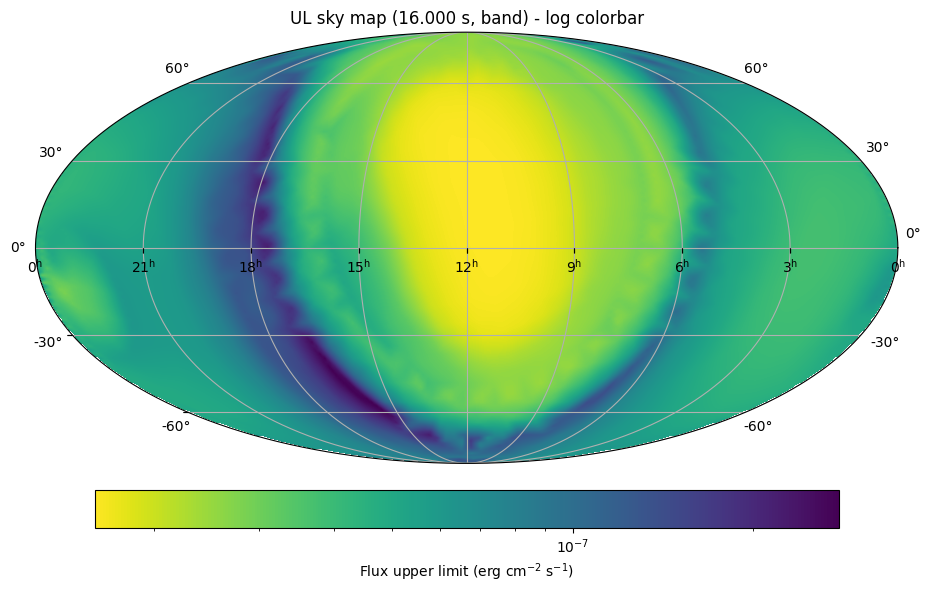

In [60]:
from matplotlib.colors import LogNorm

# ---- Plot UL map (linear map, log colorbar) ----
import matplotlib.pyplot as plt

hpx, header = hp.read_map(output_fits, h=True)

valid = np.isfinite(hpx) & (hpx > 0)
if not np.any(valid):
    raise ValueError('UL map has no positive finite pixels to plot in log scale.')

vmin = np.nanpercentile(hpx[valid], 1.0)
vmax = np.nanpercentile(hpx[valid], 99.5)

try:
    import ligo.skymap.plot  # noqa: F401

    fig = plt.figure(figsize=(12, 7), dpi=100)
    ax = plt.axes(projection='astro hours mollweide')
    ax.grid()

    image = ax.imshow_hpx(
        (hpx, 'ICRS'),
        cmap='viridis_r'
    )

    sm = plt.cm.ScalarMappable(cmap='viridis_r')
    sm.set_norm(LogNorm(vmin=vmin, vmax=vmax))
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label('Flux upper limit (erg cm$^{-2}$ s$^{-1}$)')
    plt.title(f'UL sky map ({temporal_bin_s:.3f} s, {spectrum_model}) - log colorbar')
    plt.show()

except ModuleNotFoundError:
    hp.mollview(
        hpx,
        coord='C',
        cmap='viridis_r',
        norm='log',
        min=vmin,
        max=vmax,
        title=f'UL sky map ({temporal_bin_s:.3f} s, {spectrum_model}) - log scale',
        unit='Flux upper limit (erg cm$^{-2}$ s$^{-1}$)'
    )

In [61]:
def ul_at_radec(ra_deg, dec_deg, ul_fits_path=output_fits, nest=False):
    """
    Return flux upper limit at a given sky position (RA, Dec in degrees)
    from the UL HEALPix FITS map.
    """
    ul_map = hp.read_map(ul_fits_path, nest=nest, verbose=False)
    nside = hp.get_nside(ul_map)
    pix = hp.ang2pix(nside, ra_deg, dec_deg, lonlat=True, nest=nest)
    return float(ul_map[pix])


# Example
ra_test, dec_test = 123.0, 50.0
ul_val = ul_at_radec(ra_test, dec_test)
print(f"UL at RA={ra_test:.3f}, Dec={dec_test:.3f} -> {ul_val:.3e} erg cm^-2 s^-1")

UL at RA=123.000, Dec=50.000 -> 6.202e-08 erg cm^-2 s^-1


/var/folders/5q/zf85wh2d0sxgdd55ws_1kk94pzxs0q/T/ipykernel_34482/4170089635.py:6: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
